In [2]:
import pandas as pd

In [3]:
import pandas as pd

df = pd.read_csv("breast_cancer.csv")

df = pd.get_dummies(df, drop_first=True)

print(df.head())

   Age  Tumor Size  Regional Node Examined  Reginol Node Positive  \
0   68           4                      24                      1   
1   50          35                      14                      5   
2   58          63                      14                      7   
3   58          18                       2                      1   
4   47          41                       3                      1   

   Survival Months  Race_Other  Race_White  Marital Status_Married  \
0               60       False        True                    True   
1               62       False        True                    True   
2               75       False        True                   False   
3               84       False        True                    True   
4               50       False        True                    True   

   Marital Status_Separated  Marital Status_Single   ...  \
0                     False                   False  ...   
1                     False                 

In [4]:

df = df.replace({True:1, False:0})
df.head(100)

C:\Users\dumpa\AppData\Local\Temp\ipykernel_1152\2484145089.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace({True:1, False:0})


,Age,Tumor Size,Regional Node Examined,Reginol Node Positive,Survival Months,Race_Other,Race_White,Marital Status_Married,Marital Status_Separated,Marital Status_Single,...,differentiate_Poorly differentiated,differentiate_Undifferentiated,differentiate_Well differentiated,Grade_1,Grade_2,Grade_3,A Stage_Regional,Estrogen Status_Positive,Progesterone Status_Positive,Status_Dead
0,68,4,24,1,60,0,1,1,0,0,...,1,0,0,0,0,1,1,1,1,0
1,50,35,14,5,62,0,1,1,0,0,...,0,0,0,0,1,0,1,1,1,0
2,58,63,14,7,75,0,1,0,0,0,...,0,0,0,0,1,0,1,1,1,0
3,58,18,2,1,84,0,1,1,0,0,...,1,0,0,0,0,1,1,1,1,0
4,47,41,3,1,50,0,1,1,0,0,...,1,0,0,0,0,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,60,25,17,2,50,0,1,1,0,0,...,0,0,1,1,0,0,1,1,1,0
96,50,30,4,2,25,0,1,0,0,0,...,0,0,0,0,1,0,1,1,0,1
97,61,25,10,1,73,0,1,1,0,0,...,0,0,0,0,1,0,1,1,1,0
98,50,24,3,3,63,0,1,1,0,0,...,1,0,0,0,0,1,1,1,1,1


In [ ]:
x = df.drop(columns = ['Status_Dead'])
y = df['Status_Dead']


In [8]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [18]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

c:\Users\dumpa\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [22]:
model = Sequential()

model.add(Dense(32, activation="relu", input_shape=(x_train.shape[1],)))
model.add(Dense(16, activation="relu"))
model.add(Dense(1, activation="sigmoid"))   # binary classification

model.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])

c:\Users\dumpa\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.fit(x_train,y_train,batch_size= 32,epochs=100,validation_batch_size= 0.2)

Epoch 1/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9664 - loss: 0.1022  
Epoch 2/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 998us/step - accuracy: 0.9720 - loss: 0.0857
Epoch 3/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 970us/step - accuracy: 0.9727 - loss: 0.0755
Epoch 4/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.9751 - loss: 0.0718
Epoch 5/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 943us/step - accuracy: 0.9764 - loss: 0.0689
Epoch 6/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.9776 - loss: 0.0658
Epoch 7/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9773 - loss: 0.0668
Epoch 8/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9776 - loss: 0.0637
Epoch 9/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9770 - loss: 0.0643  
Epoch 10/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9786 - loss: 0.0620  
Epoch 11/100
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9783 - loss: 0.0641  
Epoch 12/100
101/101 ━━

In [35]:
model.evaluate(x_test, y_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8522 - loss: 28.0307 


[28.03072166442871, 0.852173924446106]

In [36]:
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9868 - loss: 0.0397 - val_accuracy: 0.9643 - val_loss: 0.0673
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9880 - loss: 0.0387 - val_accuracy: 0.9689 - val_loss: 0.0685
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9895 - loss: 0.0382 - val_accuracy: 0.9627 - val_loss: 0.0860
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9895 - loss: 0.0371 - val_accuracy: 0.9581 - val_loss: 0.0911
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9895 - loss: 0.0367 - val_accuracy: 0.9596 - val_loss: 0.0983
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9899 - loss: 0.0350 - val_accuracy: 0.9565 - val_loss: 0.0985
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9895 - loss: 0.0360 - val_accuracy: 0.9534 - val_loss: 0.1157
Epoch 8/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9880 - loss: 0.0360 - val_accuracy: 0.9550 - val_loss:

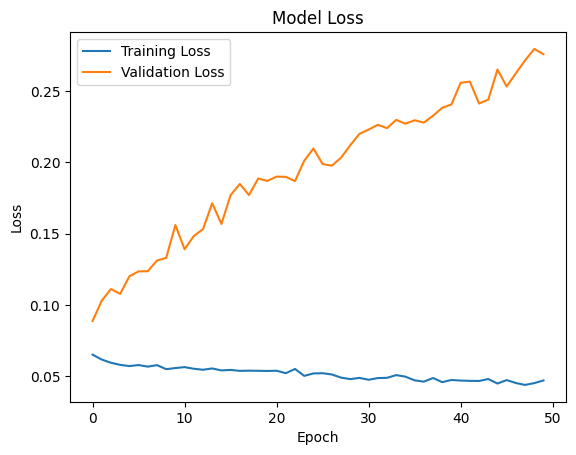

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Training Loss", "Validation Loss"])

plt.show()

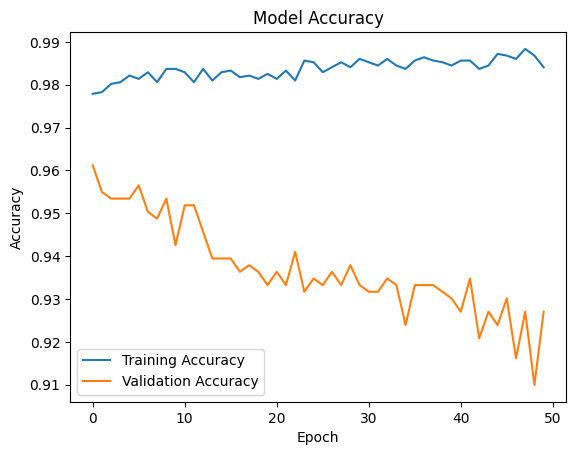

In [32]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Training Accuracy", "Validation Accuracy"])

plt.show()